Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture the heterogeneity of cell responses upon ligand exposure. 

In [1]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

lembas = '/home/hmbaghda/Projects/LEMBAS'
sys.path.insert(1, os.path.join(lembas))
from LEMBAS.model.bionetwork import format_network#, SignalingModel

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSimple
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)
sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        drop_self = True, verbose = True)

The thresholds filtered 21403  of 28277 interactions
The resources filtered 937  of 6874 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2

100%|████████████████████████████████████| 8122/8122 [00:00<00:00, 21403.03it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
# for the interactions that are labeled as both stimulating and inhibiting, relabel them as unknown (can only have one direction)
sn_ppis.loc[sn_ppis[(sn_ppis[stimulation_label] == 1) & (sn_ppis[inhibition_label] == 1)].index, 
    [stimulation_label, inhibition_label]] = [False, False]
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 

In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 619 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
0,Mapk14,Mapkapk2,1.0,True,False
1,Mapkapk2,Mapk14,0.1,False,False
2,Akt1,Chuk,1.0,True,False
3,Tp53,Atf3,1.0,True,False
4,Abl1,Tp73,1.0,True,False


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

## Scenario 1:

In [10]:
model_no = 1

The simplest scenario is:
- 1 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

To identify the two most distinct clusters, let's calculate the Euclidean distance of the cluster centroids in PC space:

In [11]:
group_label = 'TF_clusters' # ordered cateogry in obs

pca_rank = tf_adata.uns['pca']['pca_rank']
X_pca = tf_adata.obsm['X_pca'][:, :pca_rank] # PCA to pca_rank components

clf = NearestCentroid()
clf.fit(X_pca, np.array(tf_adata.obs[group_label]))
centroids = clf.centroids_ # group labels x n_pcs
ped = squareform(pdist(centroids, 'euclidean')) # euclidean distance between all centroids

max_clusters = np.unravel_index(np.argmax(ped), ped.shape)
max_clusters = [clf.classes_[i] for i in max_clusters]
print('Centroid euclidean distance in PC space is maximized between cluster {} and {} ({} PCs)'.format(*max_clusters, tf_adata.uns['pca']['pca_rank']))

ped_ = ped.copy()
np.fill_diagonal(ped_, np.inf)
min_clusters = np.unravel_index(np.argmin(ped_), ped_.shape)
min_clusters = [clf.classes_[i] for i in min_clusters]
print('Centroid euclidean distance in PC space is minimized between cluster {} and {} ({} PCs)'.format(*min_clusters, tf_adata.uns['pca']['pca_rank']))

Centroid euclidean distance in PC space is maximized between cluster 15 and 9 (8 PCs)
Centroid euclidean distance in PC space is minimized between cluster 6 and 9 (8 PCs)


Let's also get the within-cluster dispersion, as measured by WCSS. We adapt the below equation of WCSS to calculate just the inner sum for each cluster(not summing across all clusters, which gives one metric of overall dispersion) and normalize to the total number of points in the cluster:



$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2
$$


- $k$: The number of clusters.
- $C_i$: The set of points belonging to the $i$-th cluster.
- $\mathbf{x}$: A data point within a cluster $C_i$.
- $\mathbf{\mu}_i$: The centroid of the $i$-th cluster, which is the average position of all the points in $C_i$.
- $d(\mathbf{x}, \mathbf{\mu}_i)$: The distance between a data point $\mathbf{x}$ and the centroid (here calculated as Euclidean distance)

Our WCSS:

For each $k$k:
$$
\text{WCSS} = \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2 / n
$$

- $n$: The total number of points in the cluster


In [12]:
WCSS = {}
cluster_map = tf_adata.obs[['TF_clusters']].reset_index(drop = True)
for i, centroid in enumerate(centroids):
    cluster_label = clf.classes_[i]
    cluster_indeces = cluster_map[cluster_map.TF_clusters == cluster_label].index.tolist()
    cluster_points = X_pca[cluster_indeces,:]

    # squared_distances = np.sum((cluster_points - centroid) ** 2, axis=1)
    euclidean_distance = cdist(cluster_points, [centroid], 'euclidean')
    squared_distances = np.sum(euclidean_distance**2, axis = 1)

    WCSS[cluster_label] = np.sum(euclidean_distance**2)/cluster_points.shape[0]

WCSS = pd.DataFrame(WCSS.items(), columns = ['TF_cluster', 'WCSS'])
WCSS.sort_values(by = 'WCSS', ascending = True, inplace = True)
WCSS.reset_index(drop = True, inplace = True)

max_cluster, min_cluster = WCSS.loc[WCSS.WCSS.idxmax(), 'TF_cluster'], WCSS.loc[WCSS.WCSS.idxmin(),  'TF_cluster']
print('Cluster {} has the max dispersion in PC space'.format(max_cluster))
print('Cluster {} has the min dispersion in PC space'.format(min_cluster))

Cluster 8 has the max dispersion in PC space
Cluster 9 has the min dispersion in PC space


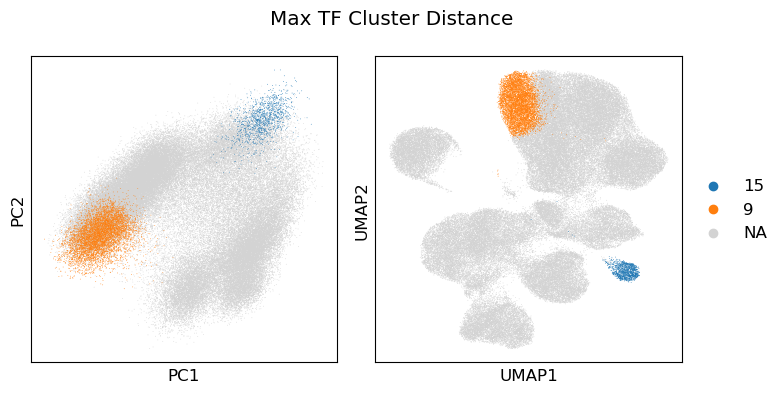

In [13]:
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [14]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(['9', '15'])]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
9     6153
15    1168
Name: count, dtype: int64

To avoid any bias, let's randomly subset the larger cluster to match the size of the smaller one:

In [15]:
sample_size = subset_tf.obs.TF_clusters.value_counts().min()
large_cluster = subset_tf.obs.TF_clusters.value_counts().idxmax()
small_cluster = subset_tf.obs.TF_clusters.value_counts().idxmin()
large_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == large_cluster].index
small_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == small_cluster].index.tolist()
np.random.seed(seed)
lcb_sub = list(np.random.choice(large_cluster_barcodes, sample_size, replace = False))
subset_tf = subset_tf[lcb_sub + small_cluster_barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
9     1168
15    1168
Name: count, dtype: int64

For now, for speed, let's subset so that there are just 100 "samples" per stimulation condition:

In [16]:
# sample_size = 100

# barcodes = []
# for cluster_label in subset_tf.obs.TF_clusters.unique():
#     bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
#     np.random.seed(seed)
#     barcodes += list(np.random.choice(bc, sample_size, replace = False))
# subset_tf = subset_tf[barcodes, :]
# subset_tf.obs.TF_clusters.value_counts()

Next, let's initialize the model:

In [17]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'9': 0, '15': 1}))
ligand_input.columns = [selected_ligand]
tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

In [18]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 'max_steps': 120, 'exp_factor':50, 'tolerance': 1e-5, 'leak':1e-2} # fed directly to model

# training parameters
lr_params = {'max_epochs': 5000, 'learning_rate': 2e-3, 'reset_optimizer_epoch': 200}
other_params = {'batch_size': 256, 'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}
regularization_params = {'param_lambda_L2': 1e-6, 'moa_lambda_L1': 0.1, 'ligand_lambda_L2': 1e-5, 'uniform_lambda_L2': 1e-4, 
                   'uniform_max': (1/projection_amplitude_out), 'spectral_loss_factor': 1e-5}
spectral_radius_params = {'n_probes_spectral': 5, 'power_steps_spectral': 50, 'subset_n_spectral': 10}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

In [19]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

Next, let's train the model:

In [ ]:
# # model setup
# mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
# mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# # loss and optimizer
# loss_fn = torch.nn.MSELoss(reduction='mean')
# optimizer = torch.optim.Adam

# # training loop
# trainer = TrainSimple(mod = mod,
#                       optimizer = torch.optim.Adam,
#                       prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
#                       hyper_params = training_params,
#                       train_split_frac = {'train': 0.8, 'test': 0.2, 'validation': None}, 
#                       train_seed = seed)
# mod, cur_loss, cur_eig, split_data_dict, stats = trainer.train_model()

# # store results
# io.write_pickled_object(stats, os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))
# torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))

# for df_type, df in split_data_dict.items():
#     if df is not None:
#         df.to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv'))

In [22]:
mod.load_state_dict(torch.load(os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth')))#, 
                              #map_location=torch.device('cpu')))
stats = io.read_pickled_object(os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))

split_data_dict = dict()
for df_type in ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']:
    fn = os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv')
    if os.path.isfile(fn):
        split_data_dict[df_type] = pd.read_csv(fn, index_col = 0)
X_test = split_data_dict['X_test']
y_train = split_data_dict['y_train']

Let's see what the output looks like:

In [ ]:
def unique_tol(arr, tol=1e-5, axis=0):
    if axis == 1:
        arr = arr.T
    norm_arr = arr / arr[:, [0]]
    
    # Sort the array based on rows
    sorted_indices = np.lexsort(norm_arr.T)
    sorted_arr = arr[sorted_indices, :]
    
    # Calculate the differences between consecutive rows
    diffs = np.diff(sorted_arr, axis=0)
    
    # Use a norm (e.g., L2 norm) to find row differences, then check against tolerance
    row_diffs = np.linalg.norm(diffs, axis=1)
    unique_row_indices = np.where(row_diffs > tol)[0]
    
    # Add the first row and the rows after significant changes
    unique_indices = np.r_[0, unique_row_indices + 1]
    
    # Select the unique rows
    unique_rows = sorted_arr[unique_indices, :]
    
    if axis == 1:
        unique_rows = unique_rows.T
        
    return unique_rows

In [ ]:
y_pred, Y_full = mod(mod.df_to_tensor(X_test))
y_pred = y_pred.cpu().detach().numpy()

y_pred_unique = unique_tol(y_pred, tol = 1e-5, axis = 0)
print('The number of unique predictions across all test data is {}'.format(len(y_pred_unique)))

We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [ ]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

# get the centroids in the full TF activity space
clf_full = NearestCentroid()
clf_full.fit(y_train, ligand_input.loc[y_train.index, selected_ligand])
train_centroids = pd.DataFrame(clf_full.centroids_ , index = clf_full.classes_, columns = y_train.columns)

# get the predictions for stimulated (1) and unstimulated (0)
y_pred_1, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 1].iloc[0, :]).T))
y_pred_1 = y_pred_1.cpu().detach().numpy()
y_pred_0, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 0].iloc[0, :]).T))
y_pred_0 = y_pred_0.cpu().detach().numpy()

# re-run the PCA on the training subset to visualize/project into this space
tf_adata_train = tf_adata[y_train.index, y_train.columns].copy()
tf_adata_train.obs.drop(columns = ['TF_clusters'], inplace = True)
tf_adata_train = embed_tf_activity(tf_adata_train, estimate_key = None, scanpy_pca = False)
tf_adata_train.TF_clusters = tf_adata[y_train.index, y_train.columns].obs.TF_clusters # replace with original clusters
pca = tf_adata_train.uns['pca']['pca_mod']

# get the train dataset centroids as well as project the predictions into pca space 
train_pca_centroids = pca.transform(train_centroids)
pred_pca_centroids = pca.transform(np.concatenate((y_pred_0, y_pred_1)))

# sanity check
clf_reduced = NearestCentroid()
clf_reduced.fit(tf_adata_train.obsm['X_pca'], ligand_input.loc[tf_adata_train.obs.index, selected_ligand])
reduced_centroids = pd.DataFrame(clf_reduced.centroids_ , index = clf_reduced.classes_)
if not np.allclose(reduced_centroids, pca_centroids):
    print('Something went wrong')

In [ ]:
width, height = 5,3
p1 = plot_embedding(adata = tf_adata_train, group_label = 'Stimulation', embedding = 'pca', 
                    palette = 'Set2', width = 3, height = 3, size = 0.1)
p1 + p9.theme(figure_size=(width, height))

In [ ]:
train_pc_rank = tf_adata_train.uns['pca']['pca_rank']
y_train_eds_full = list()
y_train_eds_reduced = list()
for idx in y_train.index:
    # full TF space
    y_vals = y_train.loc[idx, :]
    pred_type = ligand_input.loc[idx, selected_ligand]
    y_centroid = train_centroids.loc[pred_type, :]

    ed = np.linalg.norm(y_vals - y_centroid)
    y_train_eds_full.append(ed)

    # reduced space
    y_vals = tf_adata_train.obsm['X_pca'][tf_adata_train.obs.index.tolist().index(idx),:][:train_pc_rank]
    y_centroid = train_pca_centroids[train_centroids.index.tolist().index(pred_type), :][:train_pc_rank]

    ed = np.linalg.norm(y_vals - y_centroid)
    y_train_eds_reduced.append(ed)   

In [ ]:
fig, ax = plt.subplots(figsize = (12,3), ncols = 2)

colors = sns.color_palette('Set1')

sns.kdeplot(y_train_eds_full, ax = ax[0], color = colors[0])
# children = plt.gca().get_children()
l0 = ax[0].vlines(np.linalg.norm(y_pred_0 - train_centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[1])
l1 = ax[0].vlines(np.linalg.norm(y_pred_1 - train_centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[2])
ax[0].set_xlabel('Euclidean Distance to Training Centroid')
ax[0].set_title('Full TF Activity Space')

sns.kdeplot(y_train_eds_reduced, ax = ax[1], color = colors[0])
children = plt.gca().get_children()
l0 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[0,:train_pc_rank] - train_pca_centroids[0,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[1])
l1 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[1,:train_pc_rank] - train_pca_centroids[1,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[2])
ax[1].set_xlabel('Euclidean Distance to Training Centroid')
ax[1].set_title('Reduced TF Activity Space ({} PCs)'.format(train_pc_rank))

plt.legend([children[0], l0, l1], ['Training Data', 'Prediction: Unstimulated', 'Prediction: Stimulated'], 
          bbox_to_anchor=(1, 1.05))
fig.tight_layout()

In [ ]:
width, height = 5, 3

tf_adata_train.obs['Stimulation'] = ligand_input.loc[tf_adata_train.obs.index, selected_ligand]

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Stimulation], axis = 1)

# centroids and predicted values
X_centroids = pd.DataFrame(train_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])
X_pred = pd.DataFrame(pred_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])

p3 = (
    p9.ggplot() +
    p9.geom_point(X_train, p9.aes(x=X_train.columns[0], y = X_train.columns[1], color = 'Stimulation'), 
                 size = 0.1) +
    p9.scale_color_manual(values=['#66c2a5', '#fc8d62']) +
    p9.geom_point(X_centroids, p9.aes(x=X_train.columns[0], y = X_train.columns[1]), shape = 'X', color = 'black') +
    p9.geom_point(X_pred, p9.aes(x=X_pred.columns[0], y = X_pred.columns[1]), shape = '*', color = 'blue') +
    p9.xlab(col_labels[0]) + p9.ylab(col_labels[1]) + 
    p9.theme_bw() + p9.theme(figure_size=(width, height))  
    
)
p3

Altogether, these results demonstrate that bulk LEMBAS is capturing the average TF activity of a given cluster.


Some nuances:
- In full TF activity space, which the model was trained on, the predictions are very close to the average value for each condition (moreso than an individual data point). In the reduced space, they are slightly off and fall within the distribution of all training data, perhaps due to small discrepancies being amplified by loading values in the PC space. 
- Additionally, they both fall closer to each other in the PC1 direction of highest variance, indicating that they are distinguishing between the two conditions more poorly. 

This is interesting to keep in mind, indicating that those TF's that explain high levels of variance between conditions may be particularly sensitive to error. It may be worth introducing a higher penalty in the loss term for TFs with high loadings in PC1.